<a href="https://www.kaggle.com/code/hugogrou/projeto-cdg?scriptVersionId=300434310" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Inspeção Inicial do Dataset

In [1]:
#import pandas as pd

#df = pd.read_csv('/kaggle/input/datasets/hugogrou/previso-de-cliques/train.csv')



#The kernel for __notebook_source__.ipynb appears to have died. It will restart automatically.
#Your notebook tried to allocate more memory than is available. It has restarted.

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/madhu41289/avazu-ctr-prediction-exp/sampleSubmission/sampleSubmission.csv
/kaggle/input/datasets/madhu41289/avazu-ctr-prediction-exp/test/test.csv
/kaggle/input/datasets/madhu41289/avazu-ctr-prediction-exp/train/train.csv


Feito por: Bernardo e Hugo

In [3]:
import pandas as pd
import numpy as np
from IPython.display import display
from collections import defaultdict

file_path = "/kaggle/input/datasets/madhu41289/avazu-ctr-prediction-exp/train/train.csv"
chunk_size = 1_000_000

total_rows = 0
null_counts = None
columns = None
dtypes = None

# Guardar TODOS os valores numéricos
numeric_data = defaultdict(list)

# Contagens completas das categóricas
categorical_counts = defaultdict(lambda: defaultdict(int))

print("A processar dataset completo...")

for i, chunk in enumerate(pd.read_csv(file_path, chunksize=chunk_size)):
    
    total_rows += len(chunk)
    
    if i == 0:
        first_rows = chunk.head()
        columns = chunk.columns.tolist()
        dtypes = chunk.dtypes
    
    # Valores nulos globais
    if null_counts is None:
        null_counts = chunk.isnull().sum()
    else:
        null_counts += chunk.isnull().sum()
    
    # Separar tipos
    numeric_cols = chunk.select_dtypes(include=["int64", "float64"])
    categorical_cols = chunk.select_dtypes(include=["object"])
    
    # Guardar todos os valores numéricos (necessário para percentis exatos)
    for col in numeric_cols.columns:
        numeric_data[col].extend(numeric_cols[col].dropna().values)
    
    # Contagem completa categórica
    for col in categorical_cols.columns:
        counts = categorical_cols[col].value_counts()
        for key, value in counts.items():
            categorical_counts[col][key] += value

print("Processamento concluído.")


# RESULTADOS GERAIS


print("DIMENSÃO")
print((total_rows, len(columns)))

print("PRIMEIRAS 5 LINHAS")
display(first_rows)

print("TIPOS DE DADOS")
display(dtypes.to_frame("Tipo"))

print("VALORES NULOS")
display(null_counts.to_frame("Nulos"))

print("Total de valores nulos:", int(null_counts.sum()))


# ESTATÍSTICAS NUMÉRICAS COMPLETAS


print("ESTATÍSTICAS NUMÉRICAS ")

numeric_summary = {}

for col, values in numeric_data.items():
    arr = np.array(values)
    numeric_summary[col] = {
        "count": len(arr),
        "mean": np.mean(arr),
        "std": np.std(arr),
        "min": np.min(arr),
        "25%": np.percentile(arr, 25),
        "50%": np.percentile(arr, 50),
        "75%": np.percentile(arr, 75),
        "max": np.max(arr)
    }

numeric_summary_df = pd.DataFrame(numeric_summary).T
display(numeric_summary_df)


# ESTATÍSTICAS CATEGÓRICAS COMPLETAS


print("ESTATÍSTICAS CATEGÓRICAS ")

categorical_summary = {}

for col, value_dict in categorical_counts.items():
    
    total = sum(value_dict.values())
    unique = len(value_dict)
    top = max(value_dict, key=value_dict.get)
    freq = value_dict[top]
    
    categorical_summary[col] = {
        "count": total,
        "unique": unique,
        "top": top,
        "freq": freq
    }

categorical_summary_df = pd.DataFrame(categorical_summary).T
display(categorical_summary_df)


A processar dataset completo...
Processamento concluído.
DIMENSÃO
(40428967, 24)
PRIMEIRAS 5 LINHAS


,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,...,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21
0,1.000009e+18,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1,2,15706,320,50,1722,0,35,-1,79
1,1.000017e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1,0,15704,320,50,1722,0,35,100084,79
2,1.000037e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1,0,15704,320,50,1722,0,35,100084,79
3,1.000064e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1,0,15706,320,50,1722,0,35,100084,79
4,1.000068e+19,0,14102100,1005,1,fe8cc448,9166c161,0569f928,ecad2386,7801e8d9,...,1,0,18993,320,50,2161,0,35,-1,157


TIPOS DE DADOS


,Tipo
id,float64
click,int64
hour,int64
C1,int64
banner_pos,int64
site_id,object
site_domain,object
site_category,object
app_id,object
app_domain,object


VALORES NULOS


,Nulos
id,0
click,0
hour,0
C1,0
banner_pos,0
site_id,0
site_domain,0
site_category,0
app_id,0
app_domain,0


Total de valores nulos: 0
ESTATÍSTICAS NUMÉRICAS 


,count,mean,std,min,25%,50%,75%,max
id,40428967.0,9.223017e+18,5.325443e+18,5.211594e+11,4.611181e+18,9.223224e+18,1.383561e+19,1.844674e+19
click,40428967.0,1.698056e-01,3.754619e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
hour,40428967.0,1.410256e+07,2.966837e+02,1.410210e+07,1.410230e+07,1.410260e+07,1.410281e+07,1.410302e+07
C1,40428967.0,1.004968e+03,1.094586e+00,1.001000e+03,1.005000e+03,1.005000e+03,1.005000e+03,1.012000e+03
banner_pos,40428967.0,2.880146e-01,5.063820e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,7.000000e+00
device_type,40428967.0,1.015305e+00,5.274336e-01,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,5.000000e+00
device_conn_type,40428967.0,3.313150e-01,8.547935e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.000000e+00
C14,40428967.0,1.884181e+04,4.959457e+03,3.750000e+02,1.692000e+04,2.034600e+04,2.189400e+04,2.405200e+04
C15,40428967.0,3.188831e+02,2.127250e+01,1.200000e+02,3.200000e+02,3.200000e+02,3.200000e+02,1.024000e+03
C16,40428967.0,6.010201e+01,4.729538e+01,2.000000e+01,5.000000e+01,5.000000e+01,5.000000e+01,1.024000e+03


ESTATÍSTICAS CATEGÓRICAS 


,count,unique,top,freq
site_id,40428967,4737,85f751fd,14596137
site_domain,40428967,7745,c4e18dd6,15131739
site_category,40428967,26,50e219e0,16537234
app_id,40428967,8552,ecad2386,25832830
app_domain,40428967,559,7801e8d9,27237087
app_category,40428967,36,07d7df22,26165592
device_id,40428967,2686408,a99f214a,33358308
device_ip,40428967,6729486,6b9769f2,208701
device_model,40428967,8251,8a4875bd,2455470


Feito por: Bernardo e Hugo

In [4]:
import pandas as pd
import numpy as np

# CONFIGURAÇÃO
file_path = "/kaggle/input/datasets/madhu41289/avazu-ctr-prediction-exp/train/train.csv"
chunk_size = 100000

# Tipos esperados (ajustados ao Avazu)
expected_types = {
    "id": "string",
    "click": "int64",
    "hour": "string",
    "C1": "int64",
    "banner_pos": "int64",
    "site_id": "string",
    "site_domain": "string",
    "site_category": "string",
    "app_id": "string",
    "app_domain": "string"
}

# VARIÁVEIS DE CONTROLO
total_rows = 0
invalid_counts = {col: 0 for col in expected_types}
type_mismatches = []

# PROCESSAMENTO EM CHUNKS
for chunk in pd.read_csv(file_path, chunksize=chunk_size):
    
    total_rows += len(chunk)
    
    for col, expected_type in expected_types.items():
        
        if col not in chunk.columns:
            print(f"⚠ Coluna {col} não existe no dataset.")
            continue
        
        actual_type = str(chunk[col].dtype)
        
        # Verificar tipo incorreto
        if expected_type == "string":
            if actual_type not in ["object", "string"]:
                type_mismatches.append((col, actual_type, expected_type))
        else:
            if actual_type != expected_type:
                type_mismatches.append((col, actual_type, expected_type))
        
        # Converter automaticamente
        try:
            if expected_type == "int64":
                chunk[col] = pd.to_numeric(chunk[col], errors="coerce")
            
            elif expected_type == "string":
                chunk[col] = chunk[col].astype("string")
        
        except Exception as e:
            print(f"Erro ao converter {col}: {e}")
        
        # Contar valores inválidos
        invalid_counts[col] += chunk[col].isnull().sum()

# RESULTADOS FINAIS
print("\n===== VERIFICAÇÃO DE INTEGRIDADE =====\n")
print(f"Total de linhas processadas: {total_rows}\n")

print("Tipos incorretos encontrados:")
if type_mismatches:
    for col, actual, expected in type_mismatches:
        print(f" - {col}: atual={actual} | esperado={expected}")
else:
    print(" Nenhum problema de tipo encontrado.")

print("\nValores inválidos após conversão:")
for col, count in invalid_counts.items():
    print(f" - {col}: {count} valores inválidos")

print("\nVerificação concluída.")


===== VERIFICAÇÃO DE INTEGRIDADE =====

Total de linhas processadas: 40428967

Tipos incorretos encontrados:
 - id: atual=float64 | esperado=string
 - hour: atual=int64 | esperado=string
 - id: atual=float64 | esperado=string
 - hour: atual=int64 | esperado=string
 - id: atual=float64 | esperado=string
 - hour: atual=int64 | esperado=string
 - id: atual=float64 | esperado=string
 - hour: atual=int64 | esperado=string
 - id: atual=float64 | esperado=string
 - hour: atual=int64 | esperado=string
 - id: atual=float64 | esperado=string
 - hour: atual=int64 | esperado=string
 - id: atual=float64 | esperado=string
 - hour: atual=int64 | esperado=string
 - id: atual=float64 | esperado=string
 - hour: atual=int64 | esperado=string
 - id: atual=int64 | esperado=string
 - hour: atual=int64 | esperado=string
 - id: atual=uint64 | esperado=string
 - hour: atual=int64 | esperado=string
 - id: atual=float64 | esperado=string
 - hour: atual=int64 | esperado=string
 - id: atual=float64 | esperado=str

Feito por: Hugo e Bernardo

Iniciando processamento por chunks (Dataset Inteiro)...
Processamento concluído. Gerando visualizações...


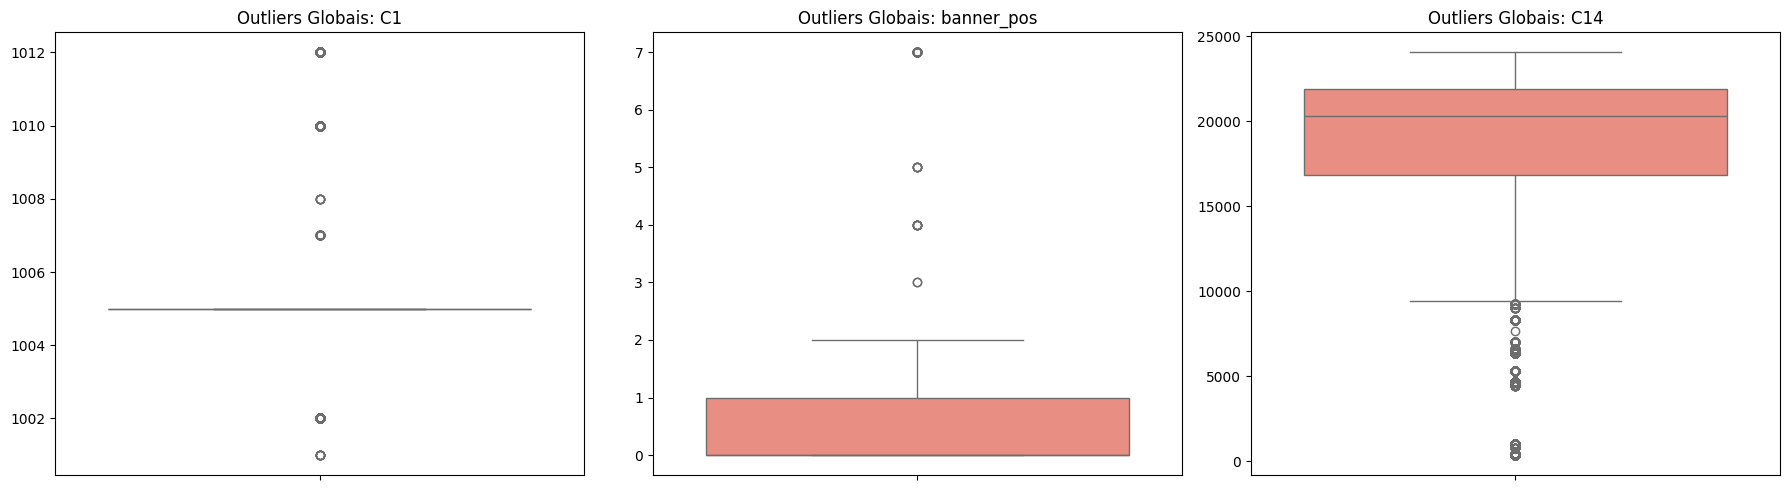

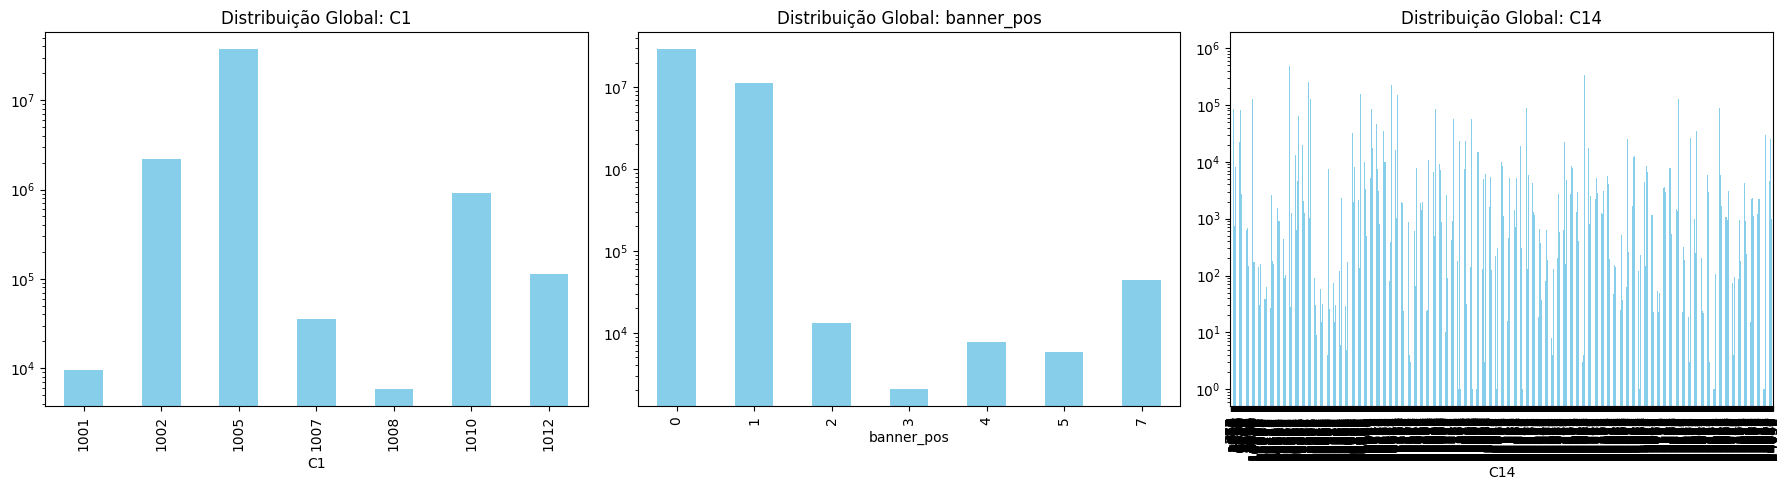

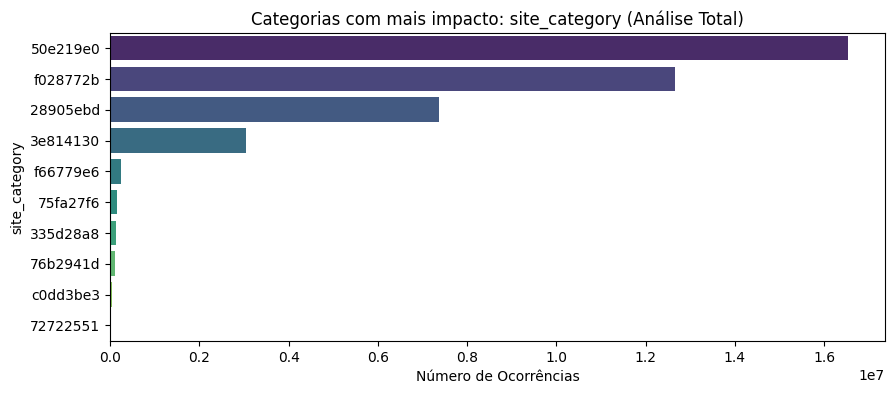

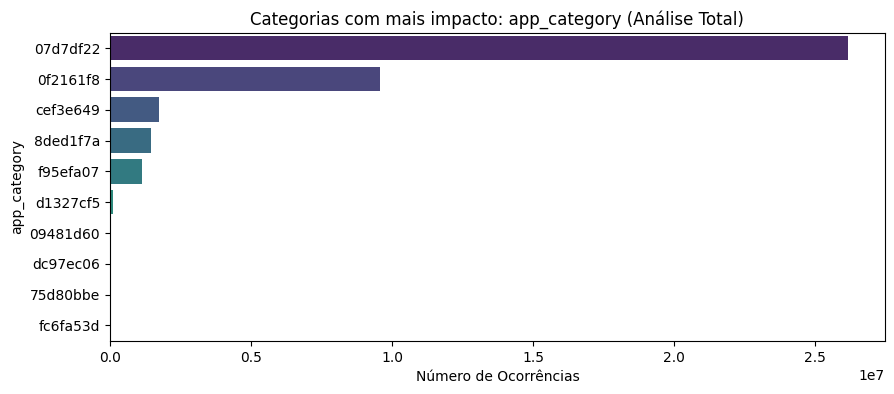

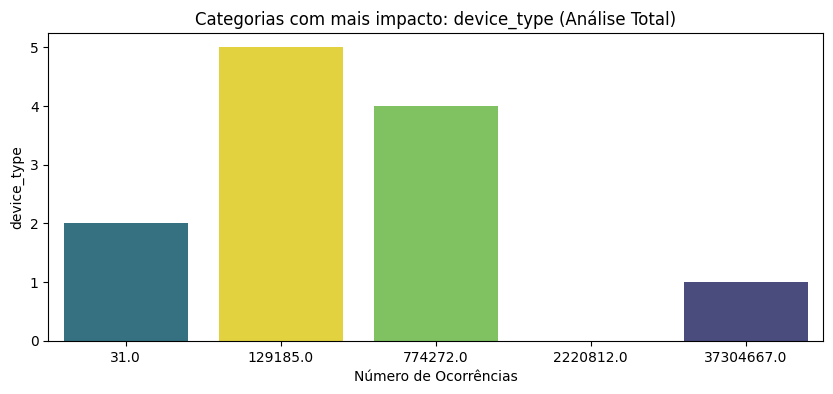

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurações Iniciais
file_path = "/kaggle/input/datasets/madhu41289/avazu-ctr-prediction-exp/train/train.csv"
chunk_size = 2_000_000  # Processar 2 milhões de linhas de cada vez
cols_numericas = ['C1', 'banner_pos', 'C14', 'C15', 'C16']
cols_categoricas = ['site_category', 'app_category', 'device_type']

# Dicionários para armazenar as agregações
counts_num = {col: pd.Series(dtype='int64') for col in cols_numericas}
counts_cat = {col: pd.Series(dtype='int64') for col in cols_categoricas}

print("Iniciando processamento por chunks (Dataset Inteiro)...")

# 2. Processamento em Loop
for chunk in pd.read_csv(file_path, chunksize=chunk_size, usecols=cols_numericas + cols_categoricas):
    # Agregar frequências para variáveis numéricas (para Boxplots)
    for col in cols_numericas:
        counts_num[col] = counts_num[col].add(chunk[col].value_counts(), fill_value=0)
    
    # Agregar frequências para variáveis categóricas
    for col in cols_categoricas:
        counts_cat[col] = counts_cat[col].add(chunk[col].value_counts(), fill_value=0)

print("Processamento concluído. Gerando visualizações...")

# ---------------------------------------------------------
# 3. Visualização de Outliers (Boxplots)
# ---------------------------------------------------------
# Como não podemos fazer boxplot de 40M de pontos diretamente, 
# usamos as contagens para criar uma amostra estatisticamente idêntica.

plt.figure(figsize=(18, 5))
for i, col in enumerate(['C1', 'banner_pos', 'C14']):
    plt.subplot(1, 3, i+1)
    
    # Criar uma série expandida baseada nas contagens para o boxplot
    # Limitamos o tamanho da amostra para o gráfico ser rápido, mas mantendo a proporção real
    v = counts_num[col].index.values
    w = counts_num[col].values
    
    sns.boxplot(y=np.repeat(v, w.astype(int) // 1000), color='salmon') # Amostra 1:1000 proporcional
    plt.title(f'Outliers Globais: {col}')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 4. Histogramas (Distribuição Global)
# ---------------------------------------------------------
plt.figure(figsize=(18, 5))
for i, col in enumerate(['C1', 'banner_pos', 'C14']):
    plt.subplot(1, 3, i+1)
    counts_num[col].sort_index().plot(kind='bar', color='skyblue')
    plt.title(f'Distribuição Global: {col}')
    plt.yscale('log') # Escala logarítmica para ver valores raros (outliers)
    
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 5. Frequência Categórica (Deep EDA)
# ---------------------------------------------------------
for col in cols_categoricas:
    plt.figure(figsize=(10, 4))
    top_10 = counts_cat[col].sort_values(ascending=False).head(10)
    
    sns.barplot(x=top_10.values, y=top_10.index, hue=top_10.index, palette='viridis', legend=False)
    plt.title(f'Categorias com mais impacto: {col} (Análise Total)')
    plt.xlabel('Número de Ocorrências')
    plt.show()

Feito por: Hugo e Bernardo


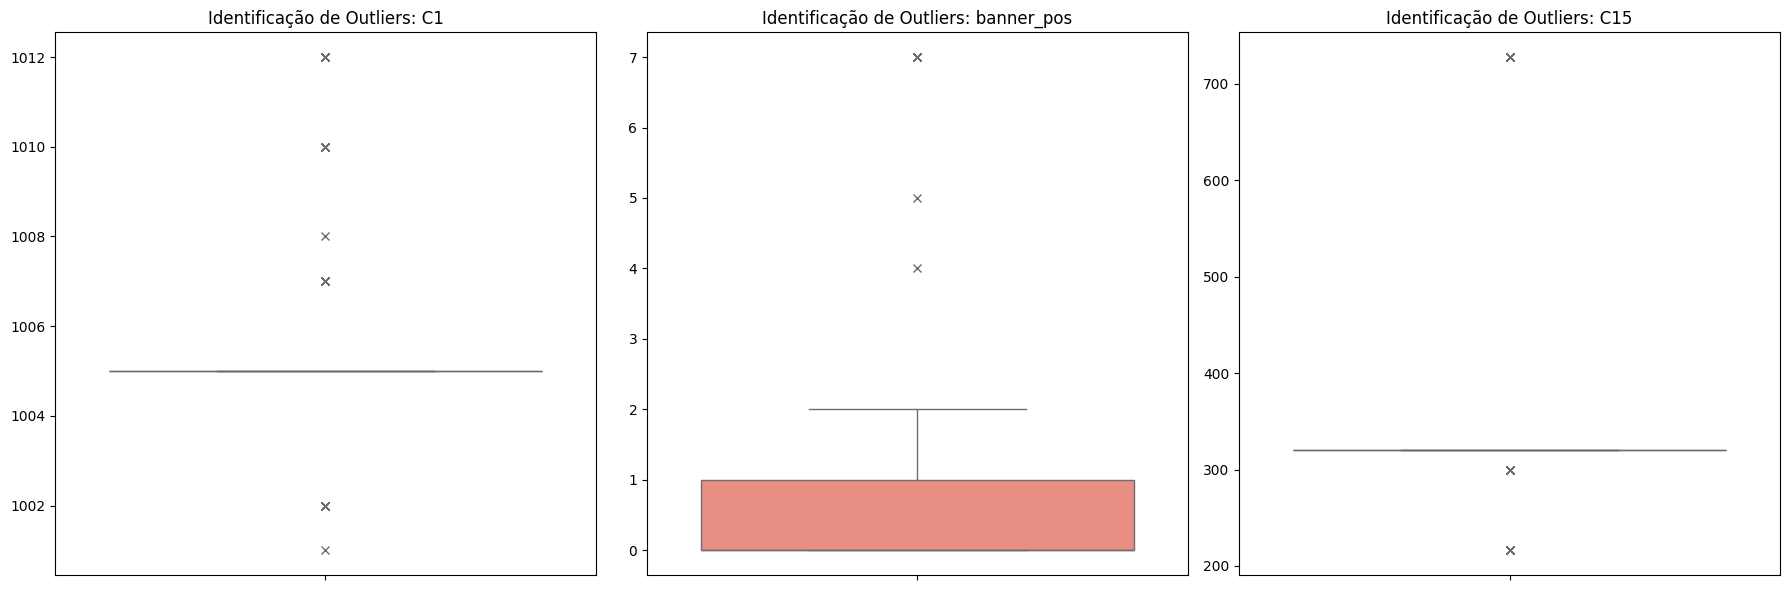

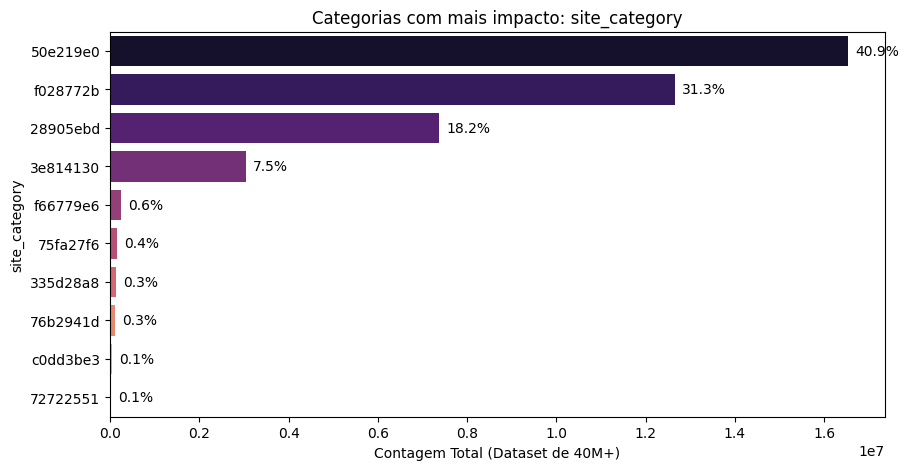

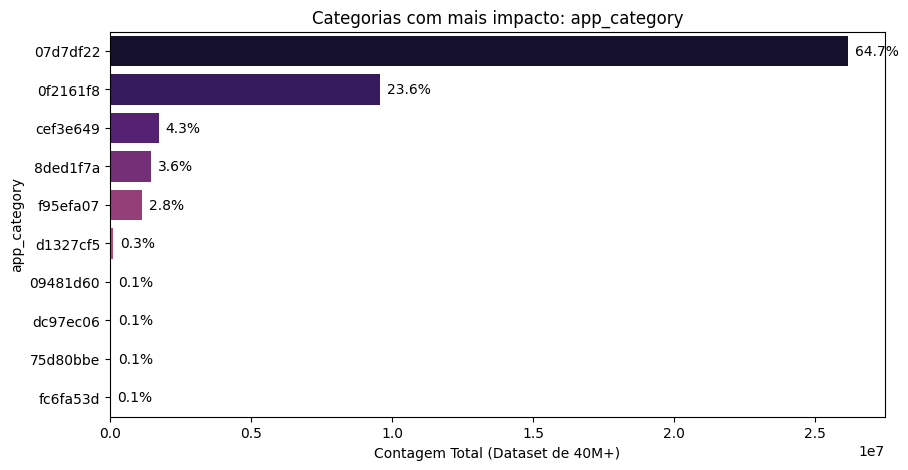

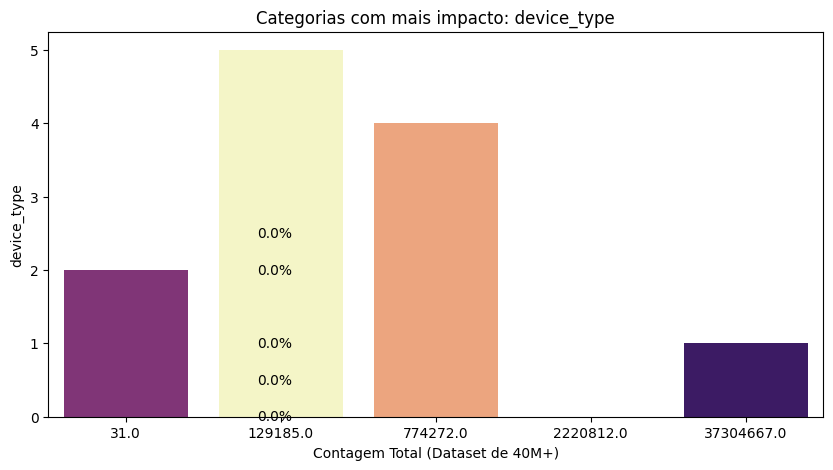

In [6]:
plt.figure(figsize=(18, 6))
cols_para_boxplot = ['C1', 'banner_pos', 'C15'] # C15 e C16 mostram bem as dimensões

for i, col in enumerate(cols_para_boxplot):
    plt.subplot(1, 3, i+1)
    
    # Criar amostra proporcional para o boxplot
    v = counts_num[col].index.values
    w = counts_num[col].values
    amostra = np.repeat(v, w.astype(int) // 5000) # Ajustado para fluidez no Kaggle
    
    # Desenhar o boxplot com destaque nos outliers
    sns.boxplot(y=amostra, color='salmon', flierprops={"marker": "x", "markerfacecolor": "red"})
    plt.title(f'Identificação de Outliers: {col}')

plt.tight_layout()
plt.show()

# --- MELHORIA: Frequência Categórica com Percentagens ---
for col in cols_categoricas:
    plt.figure(figsize=(10, 5))
    top_10 = counts_cat[col].sort_values(ascending=False).head(10)
    
    # Criar o gráfico corrigindo o erro de 'palette'
    ax = sns.barplot(x=top_10.values, y=top_10.index, hue=top_10.index, palette='magma', legend=False)
    
    # Adicionar labels de percentagem nas barras
    total_col = counts_cat[col].sum()
    for p in ax.patches:
        percentage = '{:.1f}%'.format(100 * p.get_width()/total_col)
        ax.annotate(percentage, (p.get_width(), p.get_y() + p.get_height() / 2), 
                    xytext=(5, 0), textcoords='offset points', va='center')

    plt.title(f'Categorias com mais impacto: {col}')
    plt.xlabel('Contagem Total (Dataset de 40M+)')
    plt.show()

Feito por: Hugo e Bernardo 

In [7]:
import numpy as np
import pandas as pd

def calcular_estatisticas_completas(dicionario_counts):
    resultados = []
    
    print(f"{'Coluna':<15} | {'Total Outliers':<15} | {'% do Total':<10}")
    print("-" * 45)
    
    for col, counts in dicionario_counts.items():
        # 1. Reconstruir a base para cálculos de percentis
        # Nota: Usamos amostragem ponderada para calcular Q1 e Q3 de forma eficiente
        valores = counts.index.values
        pesos = counts.values.astype(int)
        
        # Total de registos na coluna
        total_obs = pesos.sum()
        
        # Calcular Quartis (Q1 e Q3) usando a distribuição de frequências
        # Criamos uma amostra representativa para não estourar a RAM
        amostra_estatistica = np.repeat(valores, pesos // 1000) # Reduzimos escala para cálculo rápido
        
        q1 = np.percentile(amostra_estatistica, 25)
        q3 = np.percentile(amostra_estatistica, 75)
        iqr = q3 - q1
        
        # Definir limites
        limite_inferior = q1 - 1.5 * iqr
        limite_superior = q3 + 1.5 * iqr
        
        # 2. Identificar Outliers no dicionário completo
        outliers_mask = (counts.index < limite_inferior) | (counts.index > limite_superior)
        total_outliers = counts[outliers_mask].sum()
        percentagem = (total_outliers / total_obs) * 100
        
        resultados.append({
            'Coluna': col,
            'Outliers': int(total_outliers),
            'Percentagem': percentagem,
            'Limite Inf': limite_inferior,
            'Limite Sup': limite_superior
        })
        
        print(f"{col:<15} | {int(total_outliers):<15,} | {percentagem:.2f}%")
    
    return pd.DataFrame(resultados)

# Executar a função
df_outliers = calcular_estatisticas_completas(counts_num)

Coluna          | Total Outliers  | % do Total
---------------------------------------------
C1              | 3,288,335       | 8.13%
banner_pos      | 59,094          | 0.15%
C14             | 3,333,239       | 8.24%
C15             | 2,720,008       | 6.73%
C16             | 2,292,413       | 5.67%


Feito por: Bernardo e Hugo

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações visuais
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Reutilizamos o file_path e chunk_size definidos anteriormente
file_path = "/kaggle/input/datasets/madhu41289/avazu-ctr-prediction-exp/train/train.csv"
chunk_size = 1_000_000

# Variáveis para a Matriz de Correlação (apenas numéricas/ordinais)
cols_to_correlate = ['click', 'banner_pos', 'device_type', 'device_conn_type', 
                     'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21']
n_cols = len(cols_to_correlate)

# Acumuladores Matemáticos para a Correlação de Pearson Incremental
n_total_corr = 0
sum_x = np.zeros(n_cols)
sum_sq_x = np.zeros(n_cols)
sum_xy = np.zeros((n_cols, n_cols))

# Acumuladores para a Análise Bivariada (Taxa de Cliques - CTR)
hour_stats = defaultdict(lambda: {'clicks': 0, 'impressions': 0})
c14_stats = defaultdict(lambda: {'clicks': 0, 'impressions': 0})

print("A iniciar nova passagem em chunks para Bivariada e Correlação...")

for i, chunk in enumerate(pd.read_csv(file_path, chunksize=chunk_size)):
    
    # --- 1. ACUMULAÇÃO PARA CORRELAÇÃO ---
    # Garantir que lidamos apenas com numéricos para a correlação
    data = chunk[cols_to_correlate].fillna(0).values 
    n_total_corr += len(chunk)
    sum_x += data.sum(axis=0)
    sum_sq_x += (data ** 2).sum(axis=0)
    sum_xy += np.dot(data.T, data)
    
    # --- 2. ACUMULAÇÃO PARA BIVARIADA (CTR por Hora) ---
    # Extração matemática ultra-rápida: 14102100 % 100 = 0 (Hora 0)
    chunk['hora_do_dia'] = chunk['hour'] % 100
    
    grouped_hour = chunk.groupby('hora_do_dia')['click'].agg(['sum', 'count'])
    for idx, row in grouped_hour.iterrows():
        hour_stats[idx]['clicks'] += row['sum']
        hour_stats[idx]['impressions'] += row['count']
        
    # --- 3. ACUMULAÇÃO PARA BIVARIADA (CTR por C14) ---
    grouped_c14 = chunk.groupby('C14')['click'].agg(['sum', 'count'])
    for idx, row in grouped_c14.iterrows():
        c14_stats[idx]['clicks'] += row['sum']
        c14_stats[idx]['impressions'] += row['count']

print("Processamento Bivariado concluído. Pronto para gráficos.")

A iniciar nova passagem em chunks para Bivariada e Correlação...
Processamento Bivariado concluído. Pronto para gráficos.


Feito por : Bernardo e Hugo

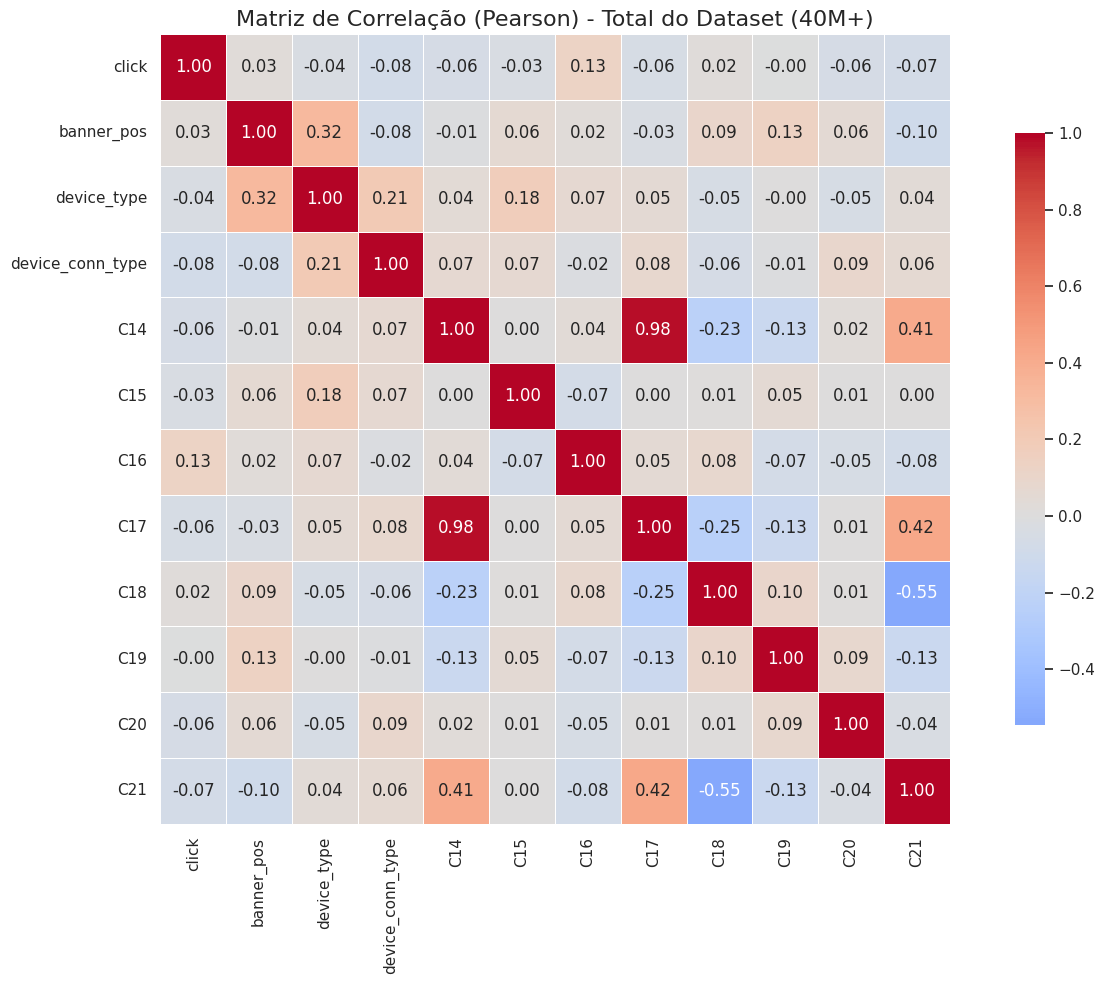


Valores de Correlação com a variável alvo ('click'):
C16 - 0.1300
device_conn_type - -0.0834
C21 - -0.0700
C14 - -0.0602
C20 - -0.0575
C17 - -0.0557
device_type - -0.0378
C15 - -0.0325
banner_pos - 0.0259
C18 - 0.0216
C19 - -0.0040


In [9]:
# --- CÁLCULO FINAL DA MATRIZ DE CORRELAÇÃO ---
# Aplicação das fórmulas estatísticas sobre os acumuladores
mean_x = sum_x / n_total_corr
cov_matrix = (sum_xy / n_total_corr) - np.outer(mean_x, mean_x)
std_x = np.sqrt((sum_sq_x / n_total_corr) - mean_x**2)

# Evitar divisão por zero caso o desvio padrão seja 0
std_x[std_x == 0] = 1 
corr_matrix = cov_matrix / np.outer(std_x, std_x)

corr_df = pd.DataFrame(corr_matrix, index=cols_to_correlate, columns=cols_to_correlate)

# Plot Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm", center=0, 
            square=True, linewidths=.5, cbar_kws={"shrink": .75})

plt.title("Matriz de Correlação (Pearson) - Total do Dataset (40M+)", fontsize=16)
plt.tight_layout()
plt.show()

# --- IMPRIMIR APENAS OS VALORES DE CORRELAÇÃO COM O ALVO ---
print("\nValores de Correlação com a variável alvo ('click'):")

# Selecionamos a coluna 'click', removemos a correlação do click com ele mesmo (que é 1.0) 
# e ordenamos para ver os mais fortes primeiro
correlacoes_alvo = corr_df['click'].drop('click').sort_values(key=abs, ascending=False)

for coluna, valor in correlacoes_alvo.items():
    print(f"{coluna} - {valor:.4f}")

Feito por: Bernardo e Hugo

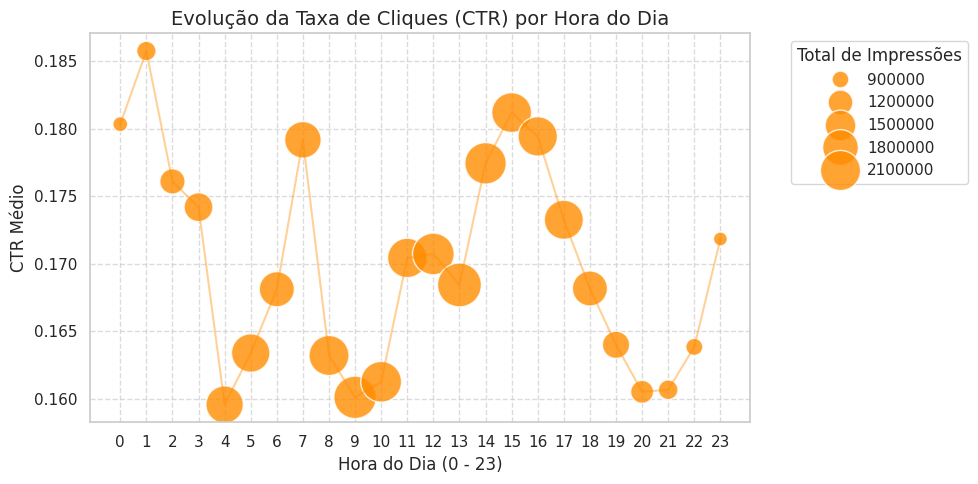

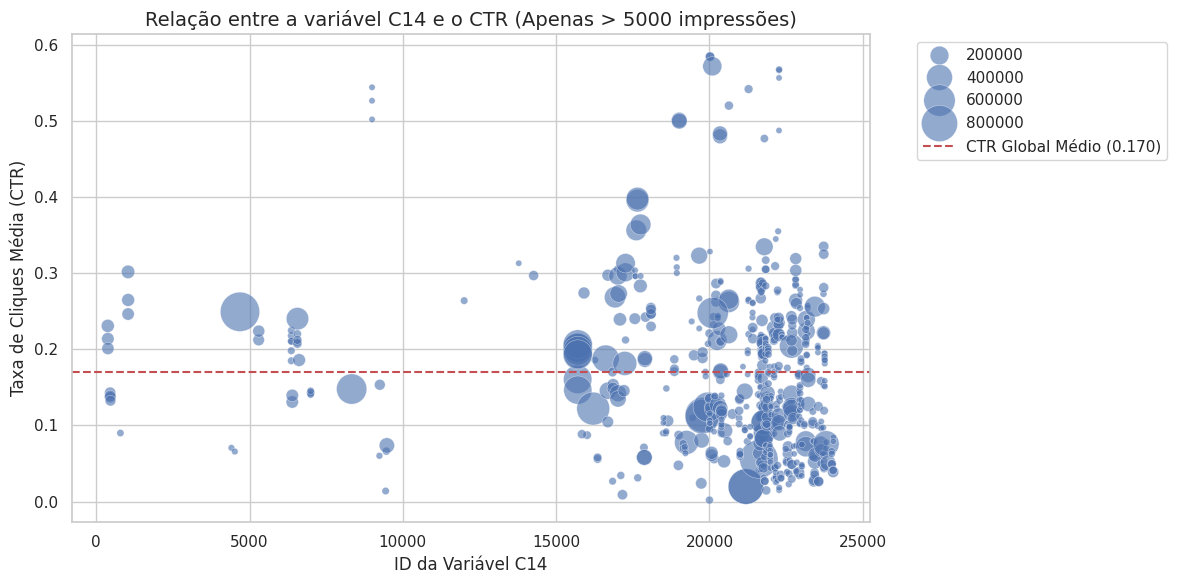

In [10]:
# Preparar DataFrames com os agregados
df_hour = pd.DataFrame.from_dict(hour_stats, orient='index').reset_index()
df_hour.rename(columns={'index': 'hora_do_dia'}, inplace=True)
df_hour['CTR'] = df_hour['clicks'] / df_hour['impressions']
df_hour.sort_values('hora_do_dia', inplace=True)

df_c14 = pd.DataFrame.from_dict(c14_stats, orient='index').reset_index()
df_c14.rename(columns={'index': 'C14'}, inplace=True)
df_c14['CTR'] = df_c14['clicks'] / df_c14['impressions']

# Filtrar ruído (C14 com poucas impressões não são estatisticamente relevantes)
df_c14_filtered = df_c14[df_c14['impressions'] > 5000]
global_ctr = df_hour['clicks'].sum() / df_hour['impressions'].sum()

# --- GRÁFICO 1: CTR ao Longo do Dia ---
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_hour, x='hora_do_dia', y='CTR', size='impressions', sizes=(100, 1000), color='darkorange', alpha=0.8)
sns.lineplot(data=df_hour, x='hora_do_dia', y='CTR', color='darkorange', alpha=0.4)
plt.title("Evolução da Taxa de Cliques (CTR) por Hora do Dia", fontsize=14)
plt.xlabel("Hora do Dia (0 - 23)")
plt.ylabel("CTR Médio")
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Total de Impressões', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# --- GRÁFICO 2: CTR vs C14 ---
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_c14_filtered, x='C14', y='CTR', size='impressions', sizes=(20, 800), alpha=0.6, color='b')
plt.title("Relação entre a variável C14 e o CTR (Apenas > 5000 impressões)", fontsize=14)
plt.xlabel("ID da Variável C14")
plt.ylabel("Taxa de Cliques Média (CTR)")
plt.axhline(global_ctr, color='r', linestyle='--', label=f'CTR Global Médio ({global_ctr:.3f})')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()